In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [36]:
red=pd.read_csv('winequality-red.csv', sep=';')
white=pd.read_csv('winequality-white.csv', sep=';')

In [37]:
red['type'] = 'red'
white['type'] = 'white'
wine = pd.concat([red, white])
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [38]:
print(f" Dataset Shape: {wine.shape}")


 Dataset Shape: (6497, 13)


In [39]:
print(f" Column Names and Data Types:")
wine.dtypes

 Column Names and Data Types:


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                     object
dtype: object

In [34]:
wine = wine.sample(frac=1).reset_index(drop=True)
wine.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,6.3,0.39,0.22,2.80,0.048,53.0,173.0,0.99304,3.24,0.45,9.8,5,white
1,7.2,0.55,0.09,1.50,0.108,16.0,151.0,0.99380,3.07,0.57,9.2,4,white
2,8.3,0.49,0.23,6.65,0.034,6.0,158.0,0.99344,3.05,0.48,11.2,5,white
3,5.9,0.24,0.12,1.40,0.035,60.0,247.0,0.99358,3.34,0.44,9.6,6,white
4,7.8,0.58,0.13,2.10,0.102,17.0,36.0,0.99440,3.24,0.53,11.2,6,red


In [41]:
wine.isnull().sum()


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

In [42]:
wine.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


1️⃣ Creating histograms...


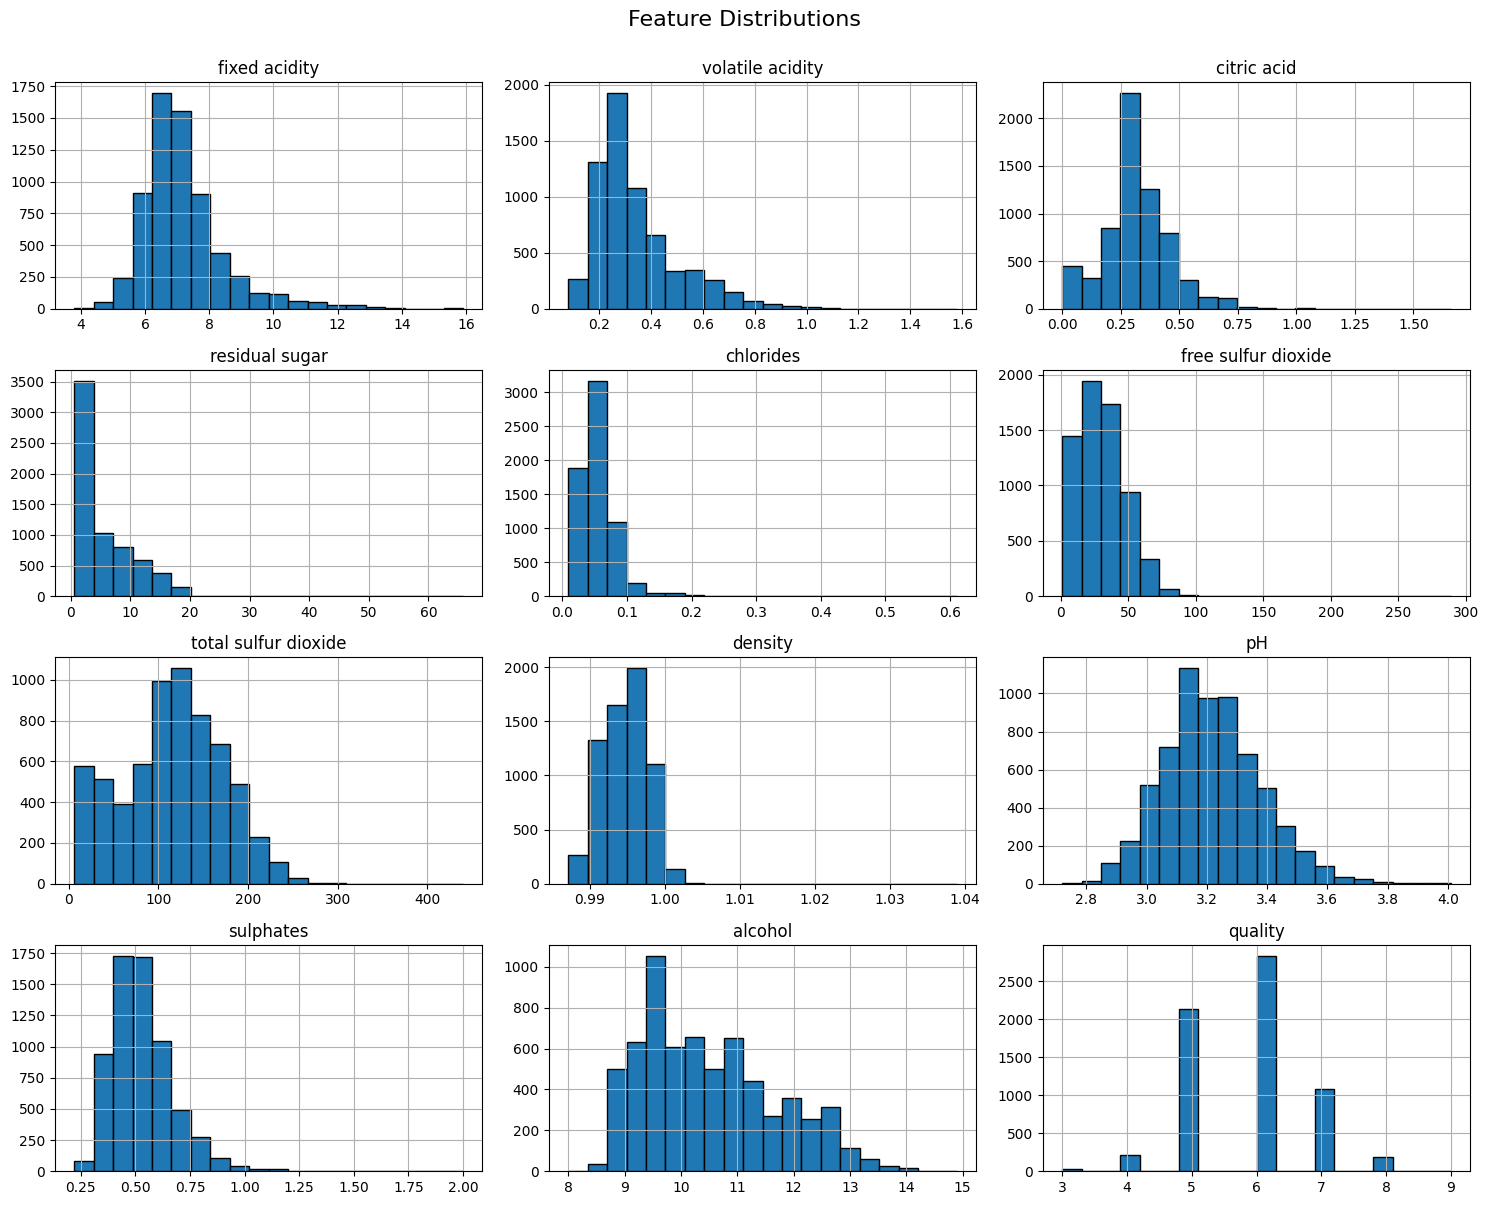

In [44]:
print("1️⃣ Creating histograms...")
wine.select_dtypes(include=[np.number]).hist(figsize=(15, 12), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

2️⃣ Creating boxplots...


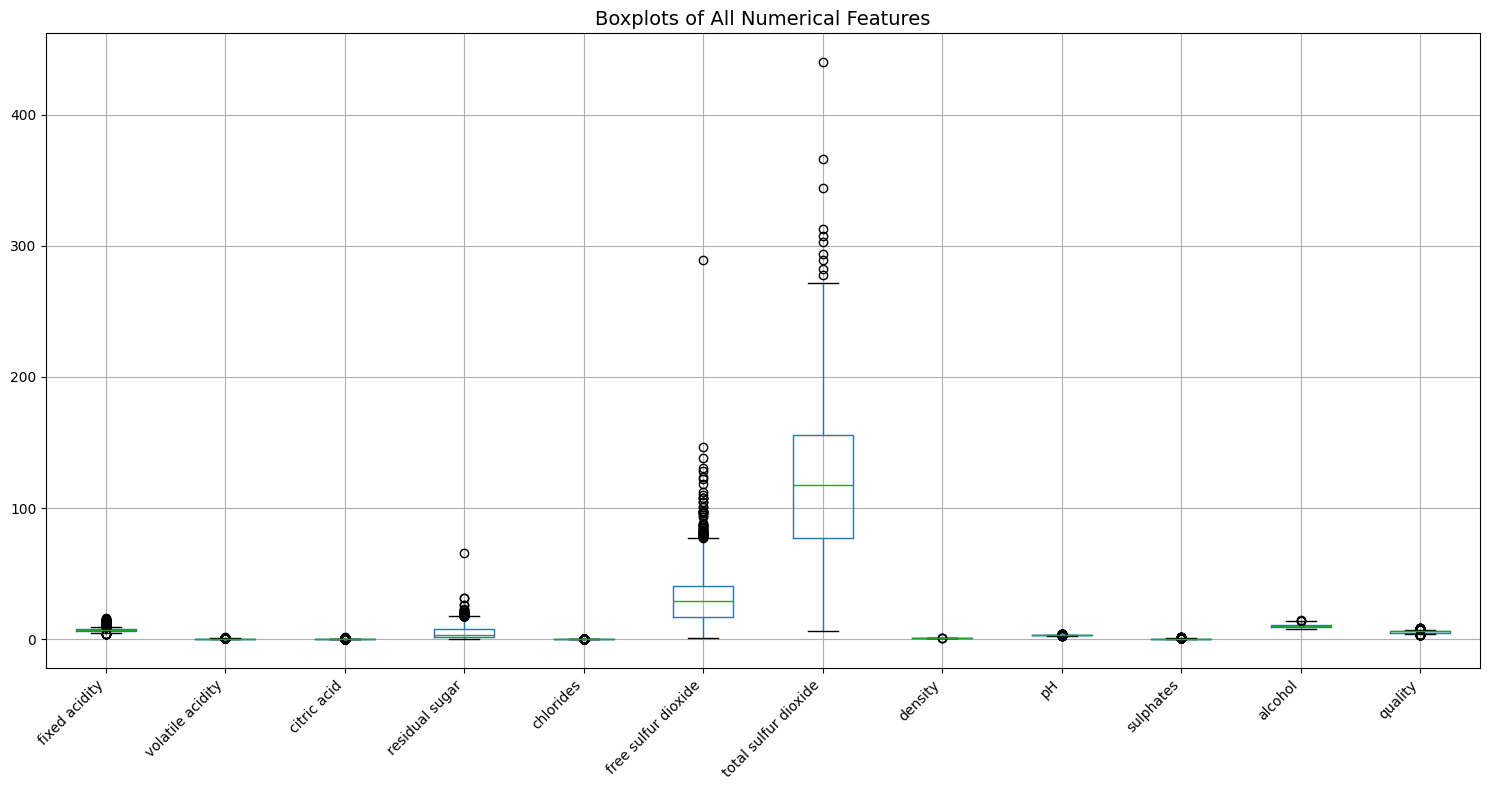

In [46]:
# 2️⃣ Boxplot for outlier detection
print("2️⃣ Creating boxplots...")
plt.figure(figsize=(15, 8))
numerical_cols = wine.select_dtypes(include=[np.number]).columns
wine[numerical_cols].boxplot(figsize=(15, 8))
plt.title("Boxplots of All Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

3️⃣ Creating correlation heatmap...


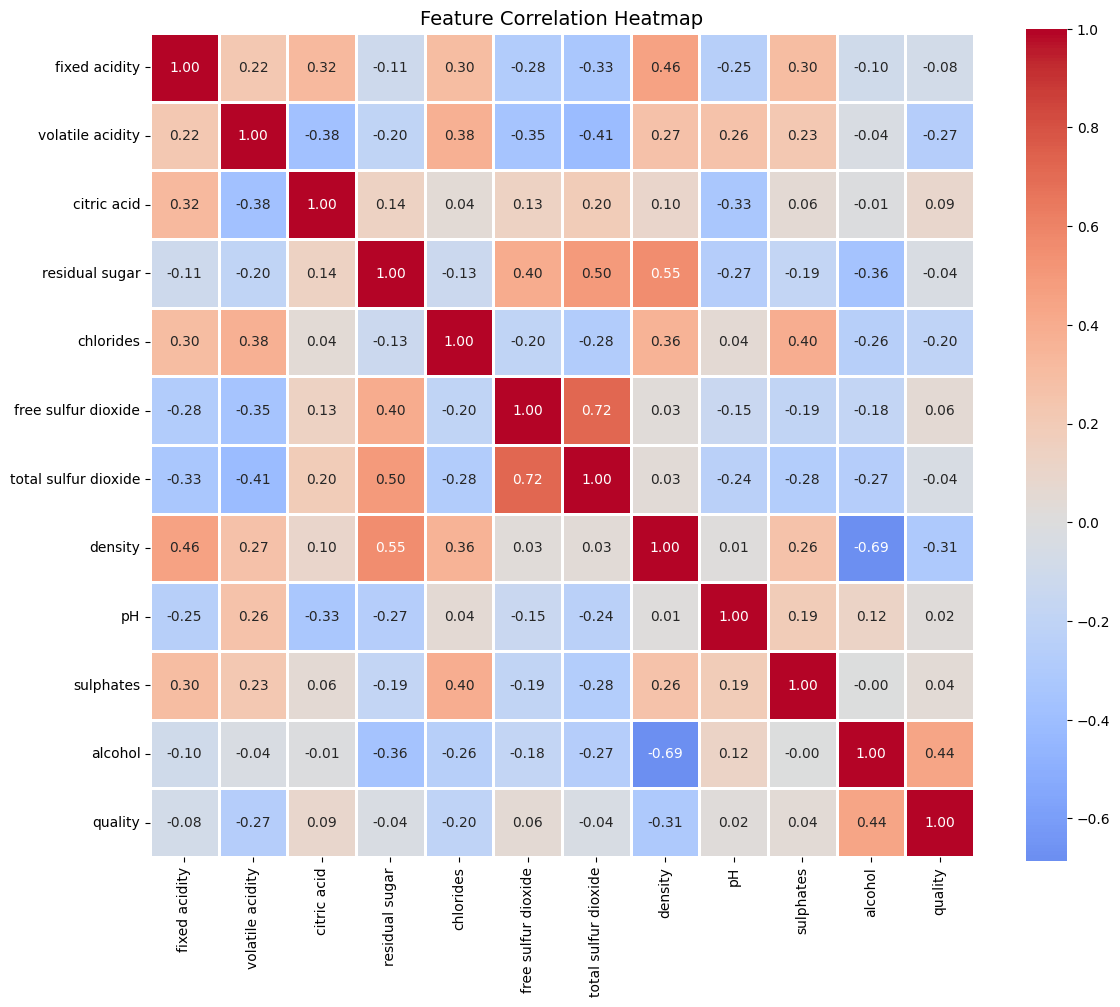

In [48]:
print("3️⃣ Creating correlation heatmap...")
plt.figure(figsize=(12, 10))
corr_matrix = wine.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap="coolwarm", 
            center=0, square=True, linewidths=1)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

4️⃣ Creating quality distribution plot...


C:\Users\aaaxx\AppData\Local\Temp\ipykernel_16876\1489195995.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=wine, palette='viridis')


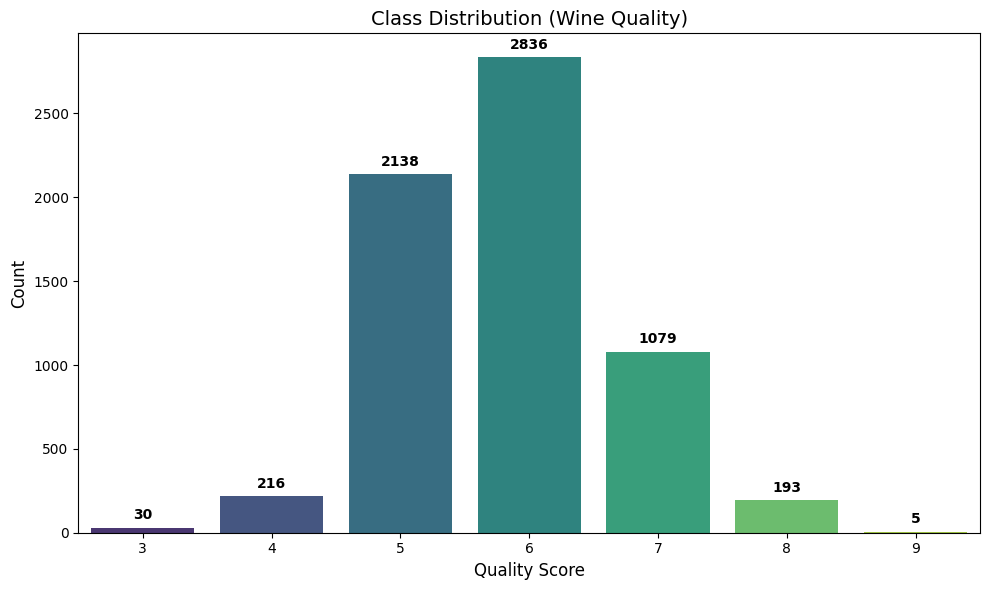

In [49]:
# 4️⃣ Quality distribution
print("4️⃣ Creating quality distribution plot...")
plt.figure(figsize=(10, 6))
quality_counts = wine['quality'].value_counts().sort_index()
sns.countplot(x='quality', data=wine, palette='viridis')
plt.title("Class Distribution (Wine Quality)", fontsize=14)
plt.xlabel("Quality Score", fontsize=12)
plt.ylabel("Count", fontsize=12)
for i, v in enumerate(quality_counts):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

5️⃣ Creating wine type distribution...


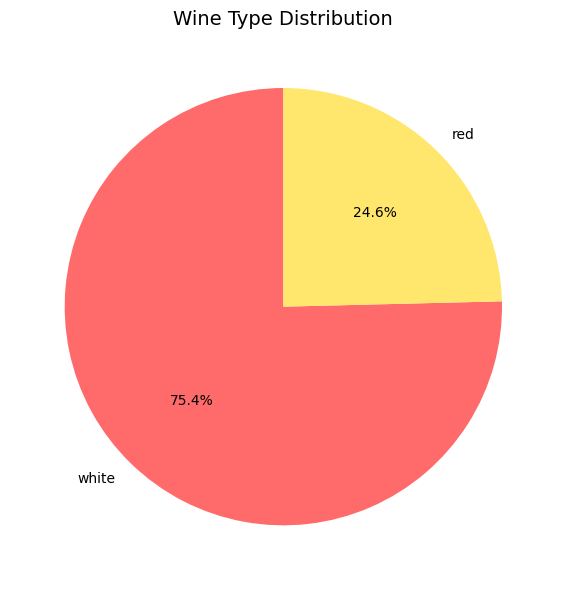

In [50]:
# 5️⃣ Wine type distribution
print("5️⃣ Creating wine type distribution...")
plt.figure(figsize=(8, 6))
type_counts = wine['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#ff6b6b', '#ffe66d'])
plt.title("Wine Type Distribution", fontsize=14)
plt.tight_layout()
plt.show()

6️⃣ Creating pairplot (this may take a moment)...


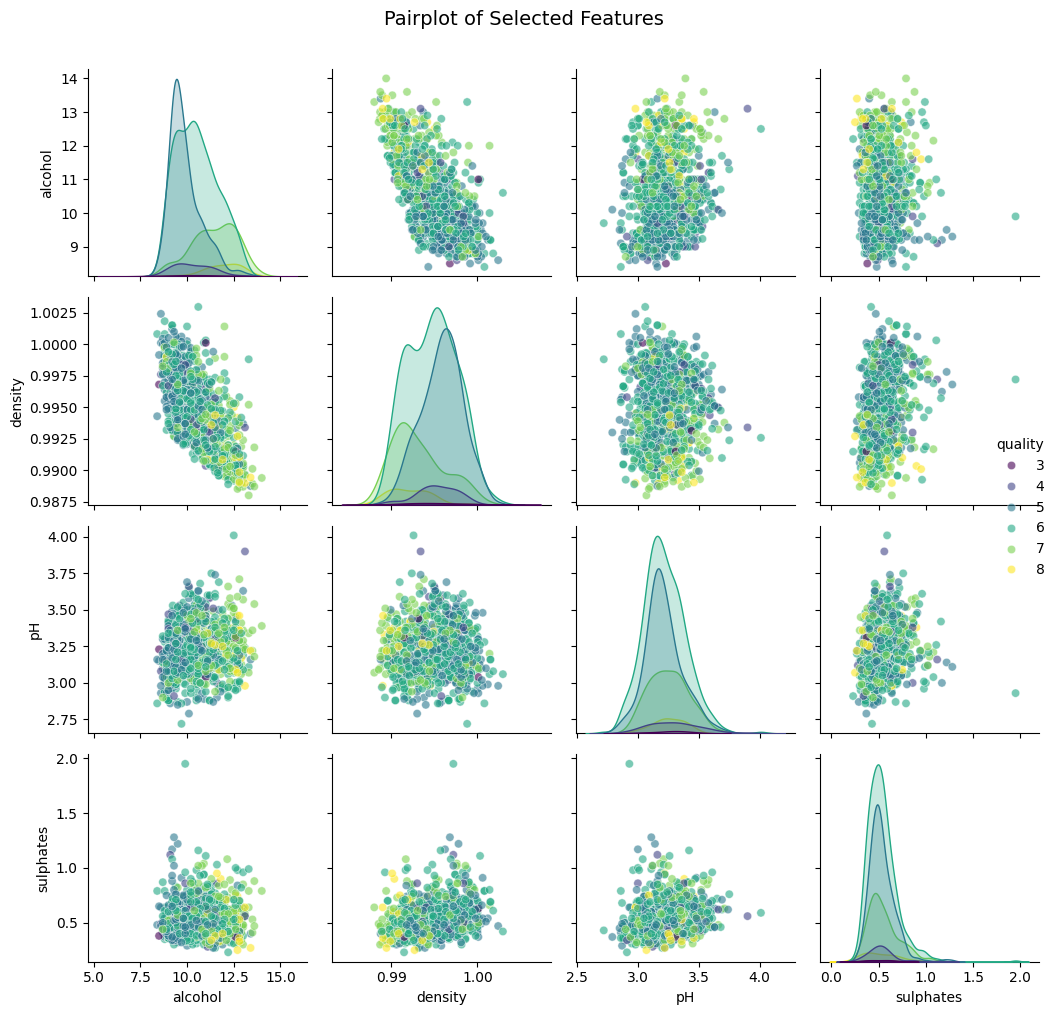

In [ ]:
# 6️⃣ Pairplot (selected features)
print("6️⃣ Creating pairplot (this may take a moment)...")
sample_wine = wine.sample(n=min(1000, len(wine)), random_state=42)
sns.pairplot(sample_wine, vars=['alcohol', 'density', 'pH', 'sulphates'], 
             hue='quality', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle("Pairplot of Selected Features", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [54]:
wine['quality'].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

In [55]:
# Oversample rare classes and undersample common ones
def oversample_class(data, label, n):
    subset = data[data['quality'] == label]
    return pd.concat([subset] * n, ignore_index=True)

quality3 = oversample_class(wine, 3, 33) if 3 in wine['quality'].values else pd.DataFrame()
quality4 = oversample_class(wine, 4, 5) if 4 in wine['quality'].values else pd.DataFrame()
quality8 = oversample_class(wine, 8, 5) if 8 in wine['quality'].values else pd.DataFrame()
quality9 = oversample_class(wine, 9, 200) if 9 in wine['quality'].values else pd.DataFrame()

# Under-sample majority classes (5–7)
quality5 = wine[wine['quality'] == 5].sample(min(1000, len(wine[wine['quality'] == 5])), random_state=42)
quality6 = wine[wine['quality'] == 6].sample(min(1000, len(wine[wine['quality'] == 6])), random_state=42)
quality7 = wine[wine['quality'] == 7].sample(min(1000, len(wine[wine['quality'] == 7])), random_state=42)

wine_balanced = pd.concat([quality3, quality4, quality5, quality6, quality7, quality8, quality9], 
                        ignore_index=True)

print("\n📊 Balanced class distribution:")
print(wine_balanced['quality'].value_counts().sort_index())


📊 Balanced class distribution:
quality
3     990
4    1080
5    1000
6    1000
7    1000
8     965
9    1000
Name: count, dtype: int64


In [56]:
# Encode 'type' column (red=0, white=1)
le = LabelEncoder()
wine_balanced['type_encoded'] = le.fit_transform(wine_balanced['type'])
print(f"✅ Encoded 'type' column: {dict(zip(le.classes_, le.transform(le.classes_)))}")


✅ Encoded 'type' column: {'red': np.int64(0), 'white': np.int64(1)}


In [57]:
# Prepare features and target
y = wine_balanced['quality'] - 3  # Shift to 0-6 range
X = wine_balanced.drop(['quality', 'type'], axis=1)  # Drop original type column
y_encoded = to_categorical(y, num_classes=7)

In [58]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [59]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded, test_size=0.30, random_state=42, stratify=y
)

# Second split: 15% validation, 15% test (50-50 split of the 30%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, 
    stratify=np.argmax(y_temp, axis=1)
)

print(f"✅ Train shape: {X_train.shape} ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"✅ Validation shape: {X_val.shape} ({X_val.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"✅ Test shape: {X_test.shape} ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")


✅ Train shape: (4924, 12) (70.0%)
✅ Validation shape: (1055, 12) (15.0%)
✅ Test shape: (1056, 12) (15.0%)


In [60]:
# Save features
pd.DataFrame(X_train, columns=X.columns).to_csv("train.csv", index=False)
pd.DataFrame(X_val, columns=X.columns).to_csv("val.csv", index=False)
pd.DataFrame(X_test, columns=X.columns).to_csv("test.csv", index=False)


In [61]:
# Save labels
np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)

In [63]:
#Save scaler for future use
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
